In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def combine_results(folder, i):
    """
    Reads the three CSV files for a given folder and index, merges them on the 'index' column, and returns a combined DataFrame.
    """

    # Load both CSVs
    df_diver = pd.read_csv(f"results/{folder}/{i}/divergence_results.csv")
    df_agent = pd.read_csv(f"results/{folder}/{i}/agent_perf.csv")
    df_loss  = pd.read_csv(f"results/{folder}/{i}/train_loss.csv")

    # Make sure index column is treated as string or integer consistently
    df_diver["index"] = df_diver["index"].astype(str)
    df_agent["index"] = df_agent["index"].astype(str)
    df_loss["index"]  = df_loss["index"].astype(str)

    # Merge and keep only shared indices
    df_common = df_diver.merge(df_agent, on="index", how="inner")
    df_common = df_common.merge(df_loss, on="index", how="inner")

    return df_common

def extractor(folder, max_i):
    """
    Combine replicates of a given experiment type (folder) and compute mean, std, and sem across replicates for each column index.
    """
    dfs = [combine_results(folder=folder, i=i) for i in range(max_i)]
    for i, df in enumerate(dfs):
        df = df.copy()
        # Clean the index column
        df["index"] = pd.to_numeric(df["index"], errors="coerce")
        dfs[i] = df

    # Stack replicates along a new "replicate" axis
    panel = pd.concat(dfs, axis=0, keys=range(len(dfs)))

    mean_df = panel.groupby(level=1).mean()
    std_df  = panel.groupby(level=1).std()
    sem_df  = std_df/np.sqrt(max_i)

    return mean_df, std_df, sem_df

def count_num_replicates(folder):
    """
    Counts the number folders that contain the three required CSV files for a given experiment type (folder).
    """
    count = 0
    for i in range(100):  # Check up to 100 replicates
        diver_path = f"results/{folder}/{i}/divergence_results.csv"
        agent_path = f"results/{folder}/{i}/agent_perf.csv"
        loss_path  = f"results/{folder}/{i}/train_loss.csv"
        if os.path.exists(diver_path) and os.path.exists(agent_path) and os.path.exists(loss_path):
            count += 1
    return count


In [70]:
folders = {
    'res_no_aux': {'line_label': 'No Auxiliary Rewards', 'color': 'slategray', 'marker': 'v'},
    'res_val_aux': {'line_label': 'Value Estimation', 'color': 'orange', 'marker': 'o'},
    'res_pred_aux': {'line_label': 'Rollout Prediction', 'color': 'green', 'marker': 'o'},
    'res_both_aux': {'line_label': 'Value + Rollout', 'color': 'blue', 'marker': 'o'},
}

<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_814800/2848169796.py:15: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel("$\epsilon$-sufficiency gap")


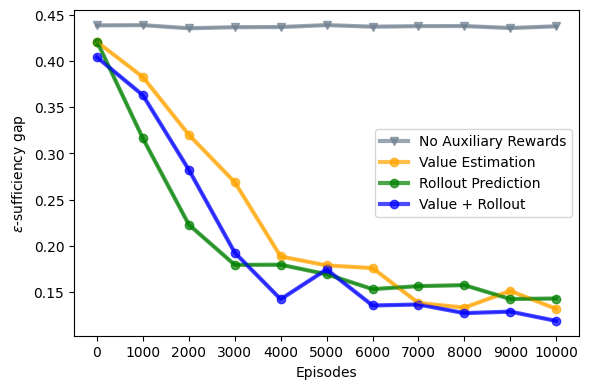

In [ ]:
x = 'index'
y = 'tv_linear'

plt.figure(figsize=(6,4))
for fold, props in folders.items():

    mean_df, std_df, sem_df = extractor(fold, count_num_replicates(fold))

    plt.plot(mean_df[x], mean_df[y], c=props['color'], linewidth=3, label = props['line_label'], alpha=0.7, marker=props['marker'])
    plt.errorbar(mean_df[x], mean_df[y],  std_df[y], color=props['color'], alpha=0.5, capsize = 5)


plt.xlabel("Episodes")
plt.xticks(mean_df[x], [f"{int(i-1)*100}" for i in mean_df[x]])
plt.ylabel("$\epsilon$-sufficiency gap")
plt.legend()
plt.tight_layout()
#plt.gca.invert_xaxis()
#plt.savefig("figures/train_succ.pdf")

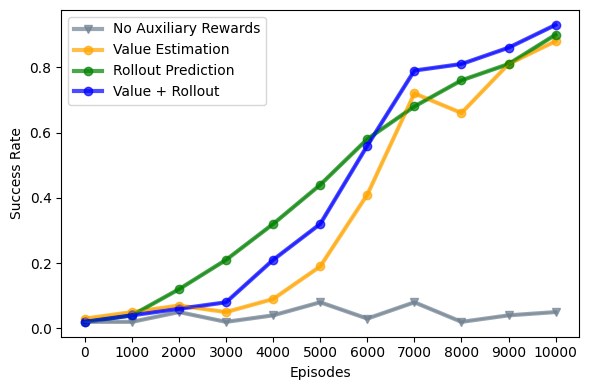

In [72]:
x = 'index'
y = 'success_rate'

plt.figure(figsize=(6,4))
for fold, props in folders.items():

    mean_df, std_df, sem_df = extractor(fold, 1)

    plt.plot(mean_df[x], mean_df[y], c=props['color'], linewidth=3, label = props['line_label'], alpha=0.7, marker=props['marker'])
    plt.errorbar(mean_df[x], mean_df[y],  std_df[y], color=props['color'], alpha=0.5, capsize = 5)


plt.xlabel("Episodes")
plt.xticks(mean_df[x], [f"{int(i-1)*100}" for i in mean_df[x]])
plt.ylabel("Success Rate")
plt.legend()
plt.tight_layout()
#plt.gca.invert_xaxis()
#plt.savefig("figures/train_succ.pdf")

Processing folder: res_val_aux


<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_814800/3447381014.py:23: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel("$\epsilon$-sufficiency gap (Total Variation)")


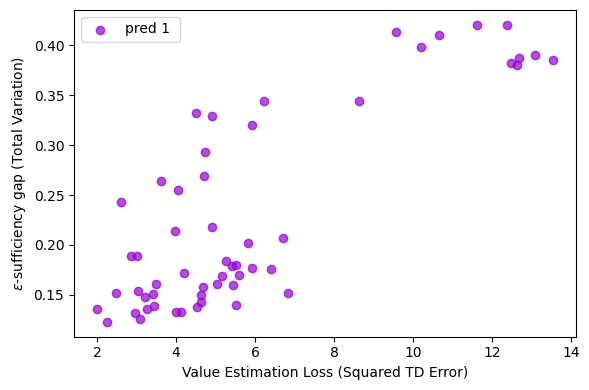

In [65]:

plt.figure(figsize=(6,4))



folders = {
    'res_val_aux': {'line_label': 'pred 1 ', 'color': 'darkviolet'},
    }
x = 'q_loss'
y = 'tv_linear'

for fold, props in folders.items():
    print(f"Processing folder: {fold}")
    for i in range(5):
        df_common = combine_results(folder=fold, i=i)
        if i == 0:
            plt.scatter(df_common[x], df_common[y], c=props['color'], alpha=0.7, label = props['line_label'])
        else:
            plt.scatter(df_common[x], df_common[y], c=props['color'], alpha=0.7)



plt.xlabel("Value Estimation Loss (Squared TD Error)")
plt.ylabel("$\epsilon$-sufficiency gap (Total Variation)")
plt.legend()
plt.tight_layout()
#plt.xlim(0.08,0.7)
#plt.ylim(0.0,1.00)
#plt.xscale('exp')
#plt.savefig("figures/KL_succ.pdf")

Processing folder: res_pred1_aux
Processing folder: res_pred2_aux
Processing folder: res_pred3_aux


<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_814800/358475337.py:25: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel("$\epsilon$-sufficiency gap (Total Variation)")


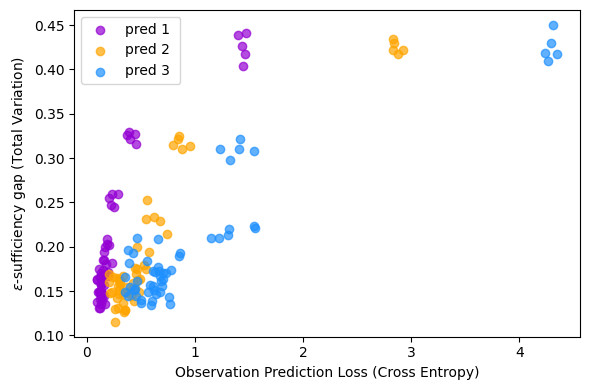

In [39]:

plt.figure(figsize=(6,4))



folders = {
    'res_pred1_aux': {'line_label': 'pred 1 ', 'color': 'darkviolet'},
    'res_pred2_aux': {'line_label': 'pred 2', 'color': 'orange'},
    'res_pred3_aux': {'line_label': 'pred 3', 'color': 'dodgerblue'},
    }
x = 'pred_o_loss'
y = 'tv_linear'

for fold, props in folders.items():
    print(f"Processing folder: {fold}")
    for i in range(5):
        df_common = combine_results(folder=fold, i=i)
        if i == 0:
            plt.scatter(df_common[x], df_common[y], c=props['color'], alpha=0.7, label = props['line_label'])
        else:
            plt.scatter(df_common[x], df_common[y], c=props['color'], alpha=0.7)



plt.xlabel("Observation Prediction Loss (Cross Entropy)")
plt.ylabel("$\epsilon$-sufficiency gap (Total Variation)")
plt.legend()
plt.tight_layout()
#plt.xlim(0.08,0.7)
#plt.ylim(0.0,1.00)
#plt.xscale('exp')
#plt.savefig("figures/KL_succ.pdf")

In [19]:
#y = 'success_rate'
y = 'linear'

mean_df, std_df, sem_df = extractor('test2',25)
mean_1 = mean_df[y].iloc[-1] 
std_1 = std_df[y].iloc[-1]
print(mean_1, std_1)

mean_df, std_df, sem_df = extractor('test',25)

mean_2 = mean_df[y].iloc[-1]
std_2 = std_df[y].iloc[-1]
print(mean_2, std_2)

mean_df, std_df, sem_df = extractor('test3',25)

mean_3 = mean_df[y].iloc[-1]
std_3 = std_df[y].iloc[-1]
print(mean_3, std_3)

mean_df, std_df, sem_df = extractor('test4',20)

mean_4 = mean_df[y].iloc[-1]
std_4 = std_df[y].iloc[-1]
print(mean_4, std_4)

# perform significance tests of the differences between all pairwise setups at the final chunk
# aussume normal distribution and use t-test
# collect pairwise results in a table, and print them
from scipy import stats
setups = [
    ("Single Vπ", mean_1, std_1),
    ("Single Vπ + Obs Pred", mean_2, std_2),
    ("Multiple Vπ", mean_3, std_3),
    ("Multiple Vπ + Obs Pred", mean_4, std_4),
]
for i in range(len(setups)):
    for j in range(i+1, len(setups)):
        name_i, mean_i, std_i = setups[i]
        name_j, mean_j, std_j = setups[j]
        # t-test
        t_stat, p_value = stats.ttest_ind_from_stats(
            mean1=mean_i, std1=std_i, nobs1=25,
            mean2=mean_j, std2=std_j, nobs2=25,
            equal_var=False
        )
        print(f"t-test between {name_i} and {name_j}: t-statistic = {t_stat:.4f}, p-value = {p_value:.6f}")

0.2331272497177124 0.01647771138066149
0.11685134310722348 0.009915073867515702
0.1471189953804016 0.01625126610402918
0.12272850984334942 0.051243932455662014
t-test between Single Vπ and Single Vπ + Obs Pred: t-statistic = 30.2317, p-value = 0.000000
t-test between Single Vπ and Multiple Vπ: t-statistic = 18.5816, p-value = 0.000000
t-test between Single Vπ and Multiple Vπ + Obs Pred: t-statistic = 10.2548, p-value = 0.000000
t-test between Single Vπ + Obs Pred and Multiple Vπ: t-statistic = -7.9496, p-value = 0.000000
t-test between Single Vπ + Obs Pred and Multiple Vπ + Obs Pred: t-statistic = -0.5630, p-value = 0.578291
t-test between Multiple Vπ and Multiple Vπ + Obs Pred: t-statistic = 2.2685, p-value = 0.030981
